# TP 3: Logistic_Regression

**Group 1: I3-AMS-TPB**<br>

**Name: NUON CHANVATHANA**<br>

**ID: e20230118**


Remarks: All models here should be built from scratch.


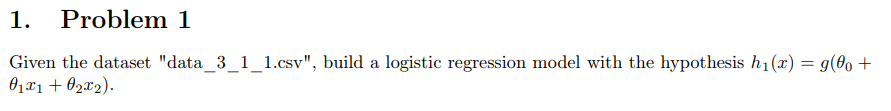

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_csv('data_3_1_1.csv')
df.head()

,x1,x2,class
0,6.70,6.79,1
1,6.92,3.87,1
2,7.87,5.36,1
3,2.93,6.91,0
4,6.67,4.92,1


In [32]:
X_train = df[['x1', 'x2']].sample(frac=0.8, random_state=42).values
X_test = df[['x1', 'x2']].drop(df.sample(frac=0.8, random_state=42).index).values
y_train = df['class'].sample(frac=0.8, random_state=42).values
y_test = df['class'].drop(df.sample(frac=0.8, random_state=42).index).values
m, n = X_train.shape
print(f"Number of training examples: {m}")

Number of training examples: 80


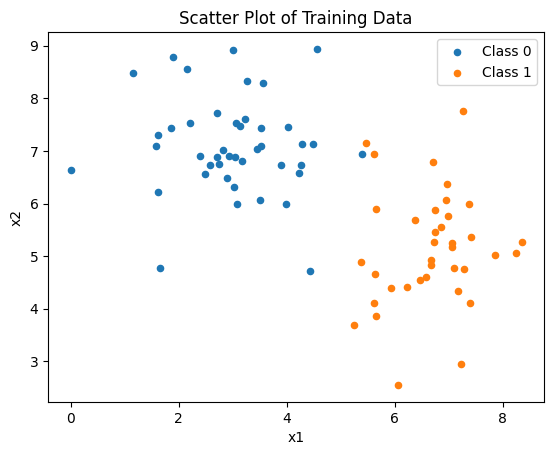

In [33]:
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='tab:blue', label='Class 0', s = 20)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='tab:orange', label='Class 1', s = 20)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Scatter Plot of Training Data')
plt.legend()
plt.show()

In [34]:
#sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

#cost function
def cost_function(X, y, w, b):
    m = X.shape[0]
    cost_sum = 0
    epsilon = 1e-15

    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)
        g = np.clip(g, epsilon, 1 - epsilon)

        cost_sum += -y[i] * np.log(g) - (1 - y[i]) * np.log(1 - g)

    return (1/m) * cost_sum

#gradient function
def gradient_function(X, y, w, b):
    m, n = X.shape
    grad_w = np.zeros(n)
    grad_b = 0

    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)

        grad_b += (g - y[i])
        for j in range(n):
            grad_w[j] += (g - y[i]) * X[i][j]


    grad_w = (1/m) * grad_w
    grad_b = (1/m) * grad_b
    return grad_w, grad_b

#gradient descent function
def gradient_descent(X, y, alpha, iterations):
    m,n = X.shape
    w = np.zeros(n)
    b = 0

    for it in range(iterations):
        grad_w, grad_b = gradient_function(X, y, w, b)

        w -= alpha * grad_w
        b -= alpha * grad_b

        if it % 100 == 0:
            cost = cost_function(X, y, w, b)
            print(f"Iteration {it}: Cost {cost_function(X, y, w, b)}")

    return w, b
                      

In [35]:
def predict(X, w, b):
    m = X.shape[0]
    preds = np.zeros(m)

    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)

        preds[i] = 1 if g >= 0.5 else 0

    return preds


In [36]:
def get_confusion_matrix(y_true, y_pred):
    # 1. Identify all unique classes and sort them for consistent indexing
    classes = sorted(list(set(y_true) | set(y_pred)))
    class_to_idx = {val: i for i, val in enumerate(classes)}
    size = len(classes)
    
    # 2. Initialize an empty (zeroed) square matrix
    matrix = [[0] * size for _ in range(size)]
    
    # 3. Fill the matrix by iterating through both lists simultaneously
    for actual, predicted in zip(y_true, y_pred):
        row = class_to_idx[actual]
        col = class_to_idx[predicted]
        matrix[row][col] += 1
        
    return matrix, classes

In [37]:
learning_rate = 0.01
num_iterations = 10000

final_w, final_b = gradient_descent(X_train, y_train, learning_rate, num_iterations)

predictions = predict(X_train, final_w, final_b)

accuracy = np.mean(predictions == y_train) * 100
print(f"Training Accuracy: {accuracy:.2f}%")

Iteration 0: Cost 0.6826646054751653
Iteration 100: Cost 0.2759924880250862
Iteration 200: Cost 0.18878848948646876
Iteration 300: Cost 0.15170856633036525
Iteration 400: Cost 0.13105931164809306
Iteration 500: Cost 0.11783098053288615
Iteration 600: Cost 0.10859825686357083
Iteration 700: Cost 0.1017705640795579
Iteration 800: Cost 0.09650666804070801
Iteration 900: Cost 0.09231886734612019
Iteration 1000: Cost 0.08890439897142438
Iteration 1100: Cost 0.08606507568373661
Iteration 1200: Cost 0.08366555699763552
Iteration 1300: Cost 0.0816101681343138
Iteration 1400: Cost 0.07982929909945036
Iteration 1500: Cost 0.07827105546427442
Iteration 1600: Cost 0.07689593415125585
Iteration 1700: Cost 0.07567331608537875
Iteration 1800: Cost 0.07457908992000285
Iteration 1900: Cost 0.07359400213468617
Iteration 2000: Cost 0.07270248647559838
Iteration 2100: Cost 0.0718918174145391
Iteration 2200: Cost 0.07115148736653142
Iteration 2300: Cost 0.07047274141660136
Iteration 2400: Cost 0.0698482248

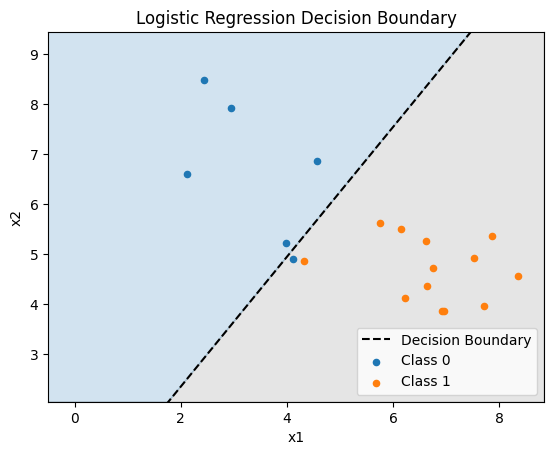

In [38]:
slope = -final_w[0] / final_w[1]
intercept = -final_b / final_w[1]

xmin, xmax = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
ymin, ymax = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5

xd = np.array([xmin, xmax])
yd = slope * xd + intercept

plt.plot(xd, yd, 'k', ls='--', label='Decision Boundary')
plt.fill_between(xd, yd, ymin, color='tab:gray', alpha=0.2)
plt.fill_between(xd, yd, ymax,color='tab:blue', alpha=0.2)

plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], c='tab:blue', label='Class 0', s = 20)
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], c='tab:orange', label='Class 1', s = 20)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.show()

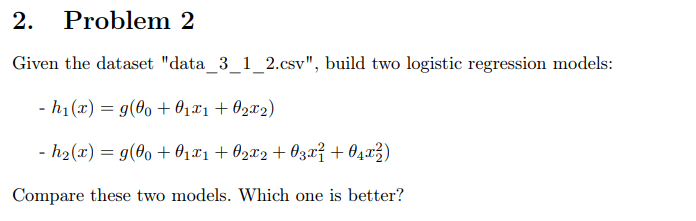

In [39]:
df_2 = pd.read_csv('data_3_1_2.csv')
df_2.head()

,x1,x2,class
0,9.076,3.721,0
1,6.809,3.930,0
2,8.256,2.851,1
3,8.461,3.145,1
4,6.783,3.188,1


In [40]:
df_2.shape

(200, 3)

In [41]:
X_train_1 = df_2[['x1', 'x2']].sample(frac=0.8, random_state=42).values
X_test_1 = df_2[['x1', 'x2']].drop(df_2.sample(frac=0.8, random_state=42).index).values
#this is correct because we use random_state=42 in both sampling and dropping to ensure the same split
y_train = df_2['class'].sample(frac=0.8, random_state=42).values
y_test = df_2['class'].drop(df_2.sample(frac=0.8, random_state=42).index).values
X_temp = df_2[['x1', 'x2']].copy()

X_temp['x1_squared'] = X_temp['x1'] ** 2
X_temp['x2_squared'] = X_temp['x2'] ** 2

X_train_2 = X_temp.sample(frac=0.8, random_state=42).values
X_test_2 = X_temp.drop(X_temp.sample(frac=0.8, random_state=42).index).values

m, n = X_train_1.shape
print("Shape of X_train_1:", X_train_1.shape)
print("Shape of X_train_2:", X_train_2.shape)
print(f"Number of training examples: {m}")

Shape of X_train_1: (160, 2)
Shape of X_train_2: (160, 4)
Number of training examples: 160


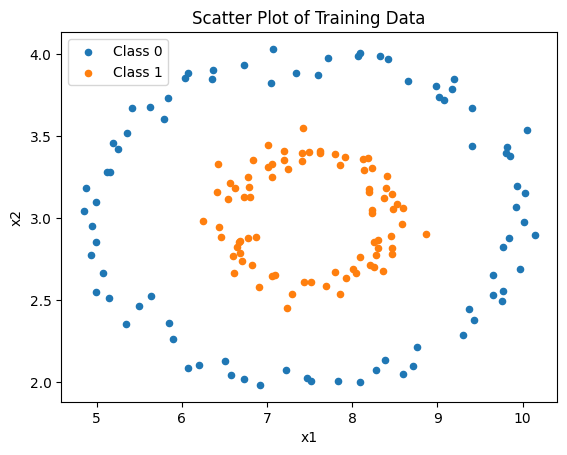

In [42]:
plt.scatter(X_train_1[y_train == 0, 0], X_train_1[y_train == 0, 1], c='tab:blue', label='Class 0', s = 20)
plt.scatter(X_train_1[y_train == 1, 0], X_train_1[y_train == 1, 1], c='tab:orange', label='Class 1', s = 20)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Scatter Plot of Training Data')
plt.legend()
plt.show()

In [43]:
learning_rate = 0.01
num_iterations = 10000

final_w, final_b = gradient_descent(X_train_1, y_train, learning_rate, num_iterations)

predictions = predict(X_train_1, final_w, final_b)
predictions.shape
accuracy = np.mean(predictions == y_train) * 100
print(f"Training Accuracy: {accuracy:.2f}%")

Iteration 0: Cost 0.6931470302667748
Iteration 100: Cost 0.6931346088811051
Iteration 200: Cost 0.6931249301799489
Iteration 300: Cost 0.6931173683780141
Iteration 400: Cost 0.6931114538583227
Iteration 500: Cost 0.6931068212378306
Iteration 600: Cost 0.6931031862328727
Iteration 700: Cost 0.6931003276583099
Iteration 800: Cost 0.6930980734217362
Iteration 900: Cost 0.6930962896263734
Iteration 1000: Cost 0.693094872092793
Iteration 1100: Cost 0.6930937397626127
Iteration 1200: Cost 0.6930928295664409
Iteration 1300: Cost 0.6930920924310171
Iteration 1400: Cost 0.6930914901726805
Iteration 1500: Cost 0.6930909930804013
Iteration 1600: Cost 0.6930905780353057
Iteration 1700: Cost 0.6930902270475929
Iteration 1800: Cost 0.6930899261182021
Iteration 1900: Cost 0.6930896643531316
Iteration 2000: Cost 0.6930894332743394
Iteration 2100: Cost 0.6930892262835813
Iteration 2200: Cost 0.6930890382452463
Iteration 2300: Cost 0.6930888651617764
Iteration 2400: Cost 0.69308870392112
Iteration 2500:

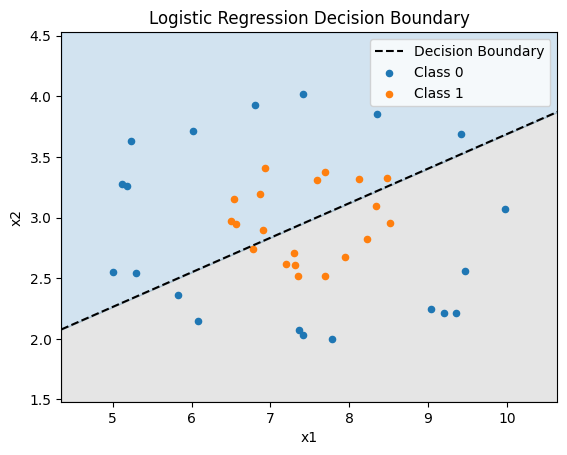

In [44]:
slope = -final_w[0] / final_w[1]
intercept = -final_b / final_w[1]

xmin, xmax = X_train_1[:, 0].min() - 0.5, X_train_1[:, 0].max() + 0.5
ymin, ymax = X_train_1[:, 1].min() - 0.5, X_train_1[:, 1].max() + 0.5

xd = np.array([xmin, xmax])
yd = slope * xd + intercept

plt.plot(xd, yd, 'k', ls='--', label='Decision Boundary')
plt.fill_between(xd, yd, ymin, color='tab:gray', alpha=0.2)
plt.fill_between(xd, yd, ymax,color='tab:blue', alpha=0.2)

plt.scatter(X_test_1[y_test == 0, 0], X_test_1[y_test == 0, 1], c='tab:blue', label='Class 0', s = 20)
plt.scatter(X_test_1[y_test == 1, 0], X_test_1[y_test == 1, 1], c='tab:orange', label='Class 1', s = 20)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.show()

In [45]:
get_confusion_matrix(y_train,predictions)

([[41, 39], [42, 38]], [np.int64(0), np.int64(1)])

In [46]:
learning_rate = 0.01
num_iterations = 10000
# Simple Z-score normalization
X_scaled = (X_train_2 - np.mean(X_train_2, axis=0)) / np.std(X_train_2, axis=0)
final_w, final_b = gradient_descent(X_scaled, y_train, learning_rate, num_iterations)
predictions = predict(X_scaled, final_w, final_b)
accuracy = np.mean(predictions == y_train) * 100
print(f"Training Accuracy: {accuracy:.2f}%")

Iteration 0: Cost 0.6931233390718421
Iteration 100: Cost 0.6912459013111883
Iteration 200: Cost 0.6899088546024128
Iteration 300: Cost 0.6887697877890578
Iteration 400: Cost 0.6877042570049292
Iteration 500: Cost 0.6866669572624695
Iteration 600: Cost 0.685641363391274
Iteration 700: Cost 0.6846214376306212
Iteration 800: Cost 0.6836049700296309
Iteration 900: Cost 0.6825911493216429
Iteration 1000: Cost 0.6815796756948479
Iteration 1100: Cost 0.6805704364472441
Iteration 1200: Cost 0.6795633873488406
Iteration 1300: Cost 0.6785585092318287
Iteration 1400: Cost 0.6775557921037715
Iteration 1500: Cost 0.6765552293330077
Iteration 1600: Cost 0.6755568155205669
Iteration 1700: Cost 0.6745605457214366
Iteration 1800: Cost 0.6735664151596978
Iteration 1900: Cost 0.6725744191244015
Iteration 2000: Cost 0.6715845529315573
Iteration 2100: Cost 0.6705968119102957
Iteration 2200: Cost 0.6696111913978626
Iteration 2300: Cost 0.6686276867378299
Iteration 2400: Cost 0.6676462932794786
Iteration 250

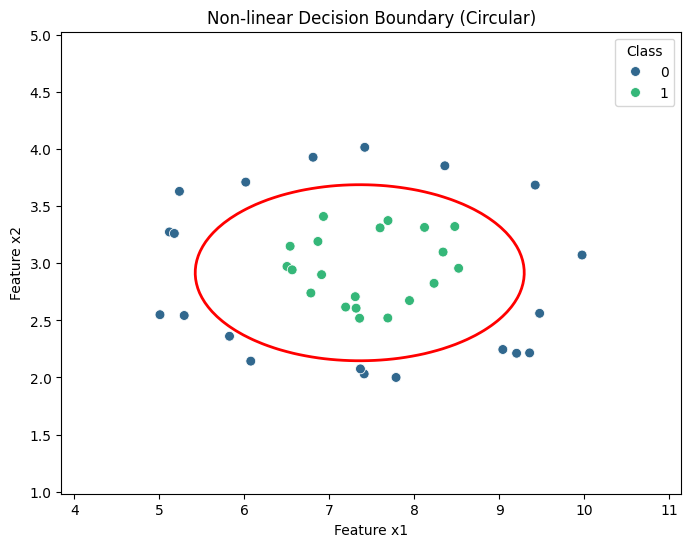

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Your weights and bias
weights = np.array([1.53313569, 1.48200905, -1.56888842, -1.53104136])
bias = -0.0001571431545626939

# 2. Get mean and std from your training data (CRITICAL for matching the scaling)
mu = np.mean(X_train_2, axis=0)
std = np.std(X_train_2, axis=0)

# 3. Create a grid of points over the range of your data
x_range = np.linspace(X_train_2[:, 0].min() - 1, X_train_2[:, 0].max() + 1, 100)
y_range = np.linspace(X_train_2[:, 1].min() - 1, X_train_2[:, 1].max() + 1, 100)
xx, yy = np.meshgrid(x_range, y_range)

# 4. Prepare the grid features to match your X_train_2 structure [x1, x2, x1^2, x2^2]
grid_points = np.c_[xx.ravel(), yy.ravel(), xx.ravel()**2, yy.ravel()**2]

# 5. Scale the grid points using the training mu and std
grid_points_scaled = (grid_points - mu) / std

# 6. Calculate Z (the linear part of the logistic regression: weights * X + bias)
# We plot the boundary where Z = 0
Z = grid_points_scaled @ weights + bias
Z = Z.reshape(xx.shape)

# 7. Plot using Seaborn and Matplotlib
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_test_2[:, 0], y=X_test_2[:, 1], hue=y_test, palette='viridis', s=50)
plt.contour(xx, yy, Z, levels=[0], colors='red', linewidths=2)

plt.title("Non-linear Decision Boundary (Circular)")
plt.xlabel("Feature x1")
plt.ylabel("Feature x2")
plt.legend(title='Class')
plt.show()

In [48]:
final_w,final_b

(array([ 1.52623082,  1.44467713, -1.58875164, -1.53170137]),
 np.float64(-0.0003815245207169876))

In [49]:
get_confusion_matrix(y_train,predictions)

([[74, 6], [0, 80]], [np.int64(0), np.int64(1)])

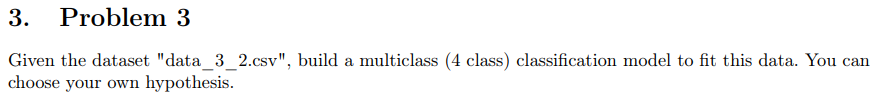

In [50]:
data = pd.read_csv('data_3_2.csv')
data.head()

,x1,x2,class
0,10.52,0.65,3
1,1.46,-1.25,2
2,1.50,0.56,2
3,-1.36,2.50,0
4,11.16,5.19,1


In [51]:
X = data[['x1', 'x2']].values
y = data['class'].values
X_train = X[:80]
y_train = y[:80]
X_test = X[80:]
y_test = y[80:]
classes = np.unique(y)
num_classes = len(classes)
print(f"Unique classes: {classes}")

Unique classes: [0 1 2 3]


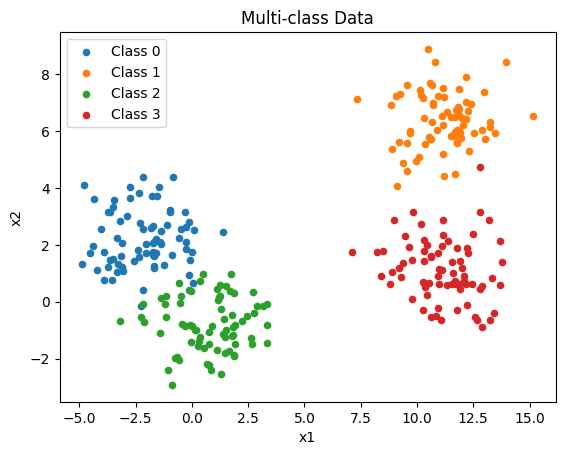

In [52]:
for c in classes:
    plt.scatter(X[y == c, 0], X[y == c, 1], label=f'Class {c}', s=20)

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Multi-class Data')
plt.legend()
plt.show()


In [53]:
weights = []
biases = []

for c in classes:
    print(f"Training classifier for class {c}")

    # Create binary labels
    y_binary = (y == c).astype(int)

    w, b = gradient_descent(X_train, y_binary[:80], alpha=0.1, iterations=1000)

    weights.append(w)
    biases.append(b)

weights = np.array(weights)
biases = np.array(biases)

Training classifier for class 0
Iteration 0: Cost 0.2783241631855548
Iteration 100: Cost 0.09976670799984019
Iteration 200: Cost 0.07243471906493712
Iteration 300: Cost 0.0580457280954136
Iteration 400: Cost 0.0489640938584355
Iteration 500: Cost 0.04265631308112958
Iteration 600: Cost 0.03798992078730316
Iteration 700: Cost 0.03437927956591574
Iteration 800: Cost 0.031490446397405746
Iteration 900: Cost 0.02911863091882156
Training classifier for class 1
Iteration 0: Cost 0.6703382892710695
Iteration 100: Cost 0.2546799346738368
Iteration 200: Cost 0.16551941114619712
Iteration 300: Cost 0.1256679115679712
Iteration 400: Cost 0.10266159930249463
Iteration 500: Cost 0.08749854764686368
Iteration 600: Cost 0.07666344039586168
Iteration 700: Cost 0.0684875428655509
Iteration 800: Cost 0.06207154156112658
Iteration 900: Cost 0.05688546331192876
Training classifier for class 2
Iteration 0: Cost 0.40639216113883814
Iteration 100: Cost 0.15210530749887852
Iteration 200: Cost 0.12054986434813

In [54]:
def predict_prob(X, w, b):
    m = X.shape[0]
    probs = np.zeros(m)

    for i in range(m):
        z = np.dot(w, X[i]) + b
        probs[i] = sigmoid(z)

    return probs

In [55]:
#predict multiclass
def predict_multiclass(X, weights, biases):
    m = X.shape[0]
    num_classes = weights.shape[0]
    probs = np.zeros((m, num_classes))

    for c in range(num_classes):
        probs[:, c] = predict_prob(X, weights[c], biases[c])

    return np.argmax(probs, axis=1)

In [56]:
predictions = predict_multiclass(X_test, weights, biases)

accuracy = np.mean(predictions == y_test) * 100
print(f"\nMulticlass Accuracy: {accuracy:.2f}%")


Multiclass Accuracy: 96.82%


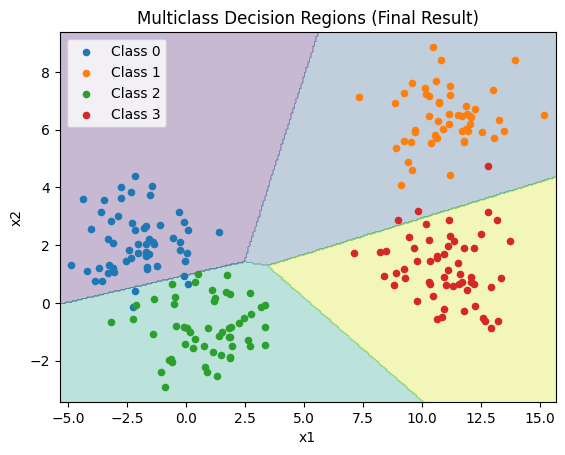

In [57]:
# Plot decision regions 
x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 300),
    np.linspace(x2_min, x2_max, 300)
)

grid = np.c_[xx1.ravel(), xx2.ravel()]

# Predict class for each grid point
Z = predict_multiclass(grid, weights, biases)
Z = Z.reshape(xx1.shape)

# Plot decision regions
plt.contourf(xx1, xx2, Z, alpha=0.3)

# Plot actual data points
for c in classes:
    plt.scatter(X_test[y_test == c, 0], X_test[y_test == c, 1], label=f'Class {c}', s=20)

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Multiclass Decision Regions (Final Result)')
plt.legend()
plt.show()

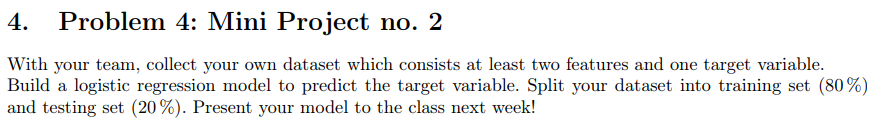